# Revenue Growth Analysis — What's Driving the Spike?

Revenue shifted direction in 2025 and posted an exceptional month in March 2026.
This notebook works through a structured decomposition to identify root causes:

1. **Monthly revenue trend** — confirm the shape of the shift
2. **Volume vs. price** — is it more orders, higher spend per order, or both?
3. **Category breakdown** — which product categories are leading the growth?
4. **Brand breakdown** — which brands within those categories?
5. **Customer mix** — new vs. returning customers driving the surge?
6. **Traffic source** — where are the customers coming from?
7. **Geography** — any geographic concentration?
8. **Margin check** — is revenue growth translating to profit, or are margins being squeezed?

## Setup

In [1]:
import sys
sys.path.append('..')
import config
import importlib
importlib.reload(config)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.cloud import bigquery

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

BQ_PROJECT = config.PROJECT_ID
DATASET    = 'ecomm_marts'

client = bigquery.Client(project=BQ_PROJECT)

# Reference period for highlighting
HIGHLIGHT_MONTH = '2026-03'

def q(sql):
    """Run a BigQuery SQL string and return a DataFrame."""
    return client.query(sql).to_dataframe()

def fmt_currency(ax, axis='y'):
    """Format an axis as $xxx,xxx."""
    fmt = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    if axis == 'y':
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

def fmt_comma(ax, axis='y'):
    fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    if axis == 'y':
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

def bar_color(month_str, highlight=HIGHLIGHT_MONTH, n_recent=3):
    """Orange = highlight month, blue = prior n months, gray = older."""
    h = pd.Period(highlight, 'M')
    m = pd.Period(month_str, 'M')
    months_before = (h.year - m.year) * 12 + (h.month - m.month)
    if months_before == 0:
        return '#e05c2a'   # orange — March 2026
    elif 1 <= months_before <= n_recent:
        return 'steelblue' # blue  — prior 3 months
    else:
        return '#c0c0c0'   # gray  — older history

print(f'Connected to {BQ_PROJECT}.{DATASET}')

Credentials set from /Users/marcalexander/projects/ai_orchestrator_claude/portfolio_ecomm/credentials/portfolio-thelook-92bf870246df.json
Project ID: portfolio-thelook
Credentials set from /Users/marcalexander/projects/ai_orchestrator_claude/portfolio_ecomm/credentials/portfolio-thelook-92bf870246df.json
Project ID: portfolio-thelook
Connected to portfolio-thelook.ecomm_marts


## 1 — Monthly Revenue Trend

Full monthly view from 2024 onward to see the shape of the shift clearly.
March 2026 is highlighted.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


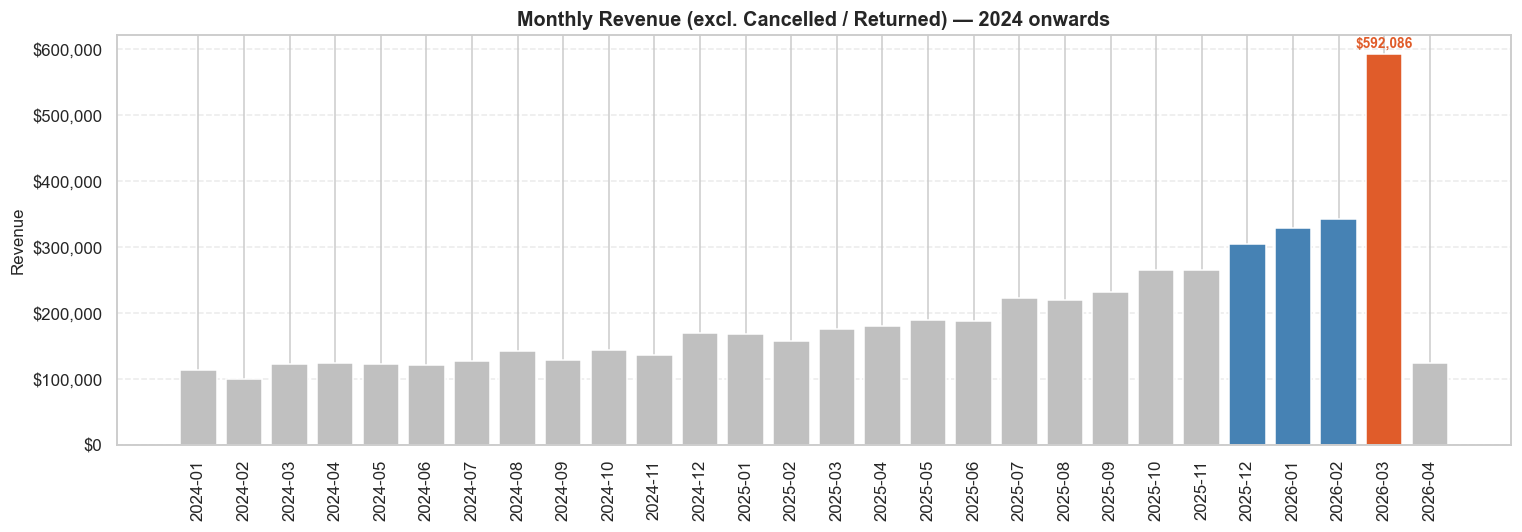

  month  orders   revenue    mom_pct
2025-11    3085 264794.56  -0.256712
2025-12    3466 304550.59  15.013915
2026-01    3724 328797.43   7.961515
2026-02    3979 343115.52   4.354684
2026-03    6968 592086.19  72.561763
2026-04    1405 124512.25 -78.970587


In [2]:
monthly_rev = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', created_at) AS month,
        COUNT(DISTINCT order_id)              AS orders,
        ROUND(SUM(revenue_amt), 2)          AS revenue
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`
    WHERE order_status NOT IN ('Cancelled', 'Returned')
      AND created_at >= '2024-01-01'
    GROUP BY 1
    ORDER BY 1
""")

colors = [bar_color(m) for m in monthly_rev['month']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly_rev['month'], monthly_rev['revenue'], color=colors, edgecolor='white')
ax.set_title('Monthly Revenue (excl. Cancelled / Returned) — 2024 onwards', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue', fontsize=11)
ax.tick_params(axis='x', rotation=90)
fmt_currency(ax)
ax.grid(axis='y', alpha=0.4, linestyle='--')

# Annotate the highlight bar
for bar, month, rev in zip(bars, monthly_rev['month'], monthly_rev['revenue']):
    if month == HIGHLIGHT_MONTH:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar.get_height() * 0.01,
                f'${rev:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#e05c2a')

plt.tight_layout()
plt.show()

# MoM and YoY deltas
monthly_rev['mom_pct'] = monthly_rev['revenue'].pct_change() * 100
print(monthly_rev[['month', 'orders', 'revenue', 'mom_pct']].tail(6).to_string(index=False))

## 2 — Volume vs. Price Decomposition

Split the revenue change into: **more orders** vs. **higher revenue per order**.
This tells us whether the driver is demand/acquisition or pricing/mix.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


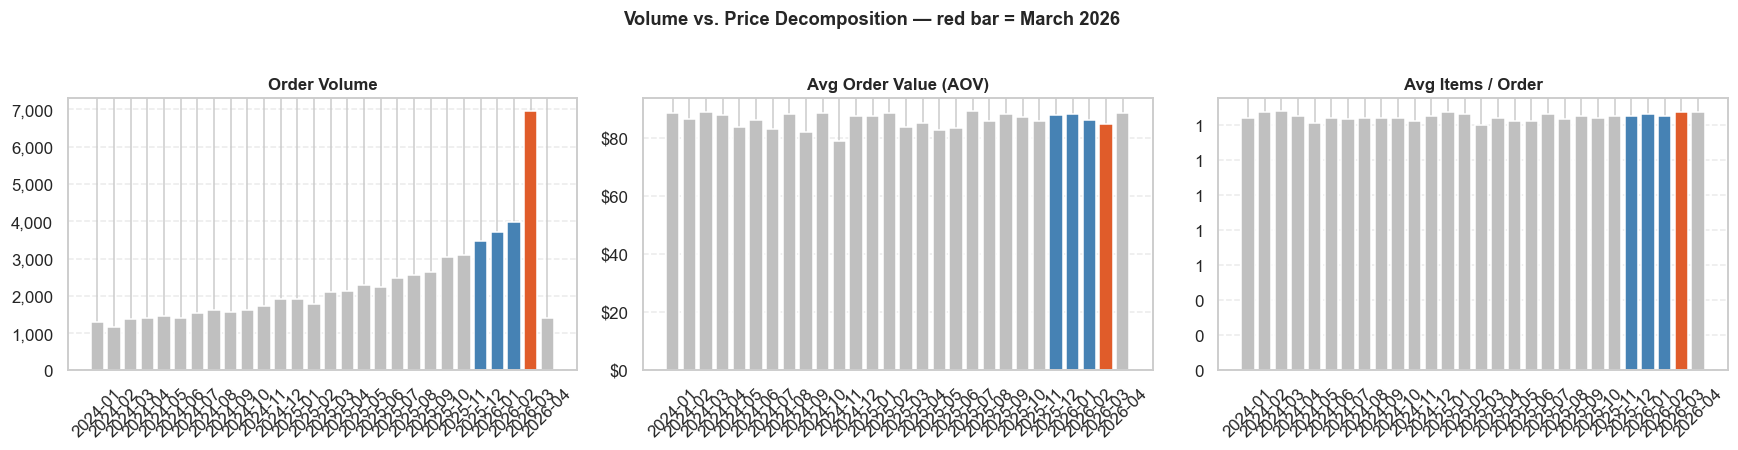

  month  orders  avg_order_value  avg_items_per_order
2025-11    3085            85.83                 1.45
2025-12    3466            87.87                 1.45
2026-01    3724            88.29                 1.46
2026-02    3979            86.23                 1.45
2026-03    6968            84.97                 1.47
2026-04    1405            88.62                 1.47


In [3]:
vol_price = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', created_at)          AS month,
        COUNT(DISTINCT order_id)                       AS orders,
        ROUND(SUM(revenue_amt), 2)                   AS revenue,
        ROUND(AVG(revenue_amt), 2)                   AS avg_order_value,
        ROUND(AVG(line_item_cnt), 2)                   AS avg_items_per_order
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`
    WHERE order_status NOT IN ('Cancelled', 'Returned')
      AND created_at >= '2024-01-01'
    GROUP BY 1
    ORDER BY 1
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [
    ('orders',            'Order Volume',          False),
    ('avg_order_value',   'Avg Order Value (AOV)', True),
    ('avg_items_per_order','Avg Items / Order',    False),
]

for ax, (col, title, is_currency) in zip(axes, metrics):
    bar_colors = [bar_color(m) for m in vol_price['month']]
    ax.bar(vol_price['month'], vol_price[col], color=bar_colors, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    if is_currency:
        fmt_currency(ax)
    else:
        fmt_comma(ax)

plt.suptitle('Volume vs. Price Decomposition — red bar = March 2026', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(vol_price[['month', 'orders', 'avg_order_value', 'avg_items_per_order']].tail(6).to_string(index=False))

## 3 — Category Breakdown

Compare March 2026 revenue by category against the prior 3-month average
to surface which categories over-indexed this month.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


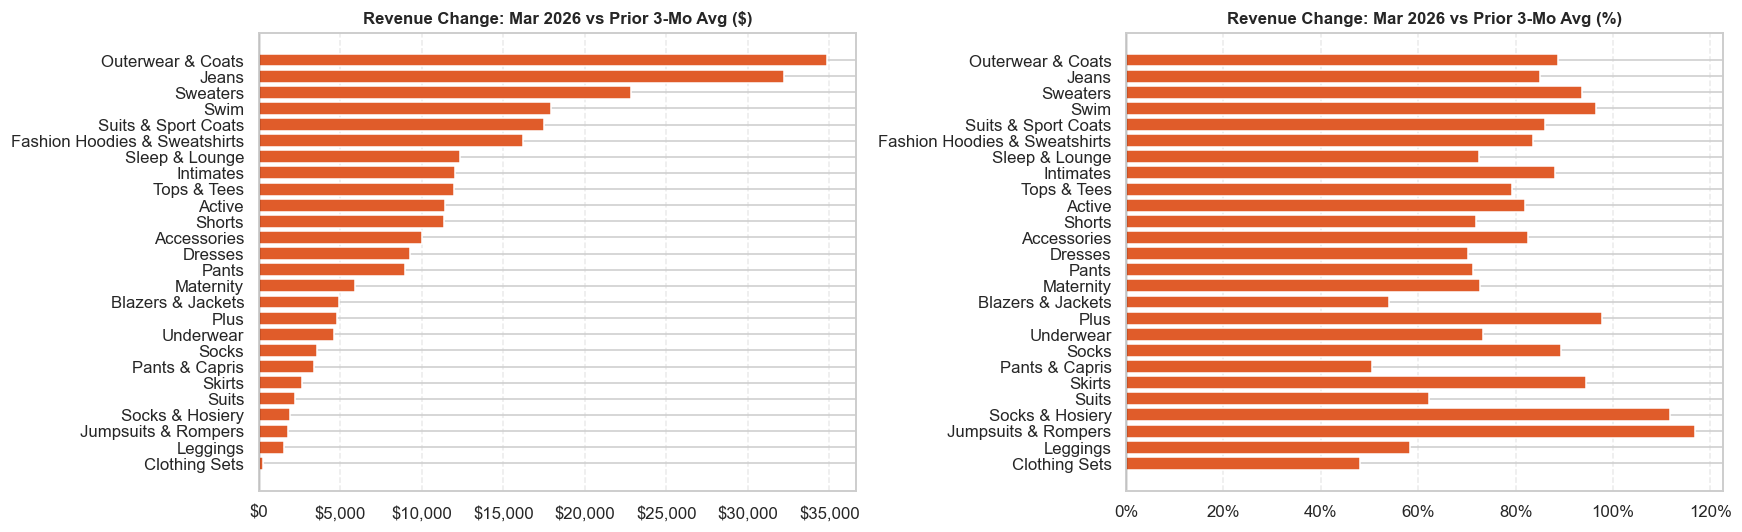

                               Mar 2026  Prior 3-Mo Avg  Change $  Change %
category                                                                   
Outerwear & Coats               74210.0         39324.0   34886.0      89.0
Jeans                           70140.0         37931.0   32209.0      85.0
Sweaters                        47196.0         24382.0   22814.0      94.0
Swim                            36529.0         18586.0   17944.0      97.0
Suits & Sport Coats             37832.0         20339.0   17493.0      86.0
Fashion Hoodies & Sweatshirts   35581.0         19381.0   16200.0      84.0
Sleep & Lounge                  29403.0         17050.0   12353.0      72.0
Intimates                       25744.0         13688.0   12056.0      88.0
Tops & Tees                     27073.0         15109.0   11965.0      79.0
Active                          25346.0         13925.0   11421.0      82.0
Shorts                          27182.0         15819.0   11363.0      72.0
Accessories 

In [4]:
cat_trend = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', o.created_at) AS month,
        p.category,
        ROUND(SUM(i.sale_price), 2)             AS revenue,
        COUNT(DISTINCT o.order_id)              AS orders
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`      o
    JOIN `{BQ_PROJECT}.{DATASET}.fct_order_items` i USING (order_id)
    JOIN `{BQ_PROJECT}.{DATASET}.dim_products`    p ON i.product_id = p.product_id
    WHERE o.order_status NOT IN ('Cancelled', 'Returned')
      AND o.created_at >= '2025-12-01'
    GROUP BY 1, 2
    ORDER BY 1, 3 DESC
""")

# Pivot: categories as columns, months as rows
cat_pivot = cat_trend.pivot_table(index='month', columns='category', values='revenue', aggfunc='sum').fillna(0)

# March 2026 vs prior 3-month average
mar26 = cat_pivot.loc[HIGHLIGHT_MONTH] if HIGHLIGHT_MONTH in cat_pivot.index else None
prior = cat_pivot[cat_pivot.index < HIGHLIGHT_MONTH].tail(3).mean()
cat_delta = pd.DataFrame({'Mar 2026': mar26, 'Prior 3-Mo Avg': prior})
cat_delta['Change $'] = cat_delta['Mar 2026'] - cat_delta['Prior 3-Mo Avg']
cat_delta['Change %'] = ((cat_delta['Mar 2026'] / cat_delta['Prior 3-Mo Avg']) - 1) * 100
cat_delta = cat_delta.sort_values('Change $', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_delta = ['#e05c2a' if v >= 0 else '#888' for v in cat_delta['Change $']]
axes[0].barh(cat_delta.index, cat_delta['Change $'], color=colors_delta)
axes[0].set_title('Revenue Change: Mar 2026 vs Prior 3-Mo Avg ($)', fontsize=11, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()
fmt_currency(axes[0], axis='x')
axes[0].grid(axis='x', alpha=0.4, linestyle='--')

axes[1].barh(cat_delta.index, cat_delta['Change %'], color=colors_delta)
axes[1].set_title('Revenue Change: Mar 2026 vs Prior 3-Mo Avg (%)', fontsize=11, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].grid(axis='x', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

print(cat_delta[['Mar 2026', 'Prior 3-Mo Avg', 'Change $', 'Change %']].round(0).to_string())


## 4 — Top Brands in March 2026

Within the categories that drove growth, which brands are doing the heavy lifting?

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


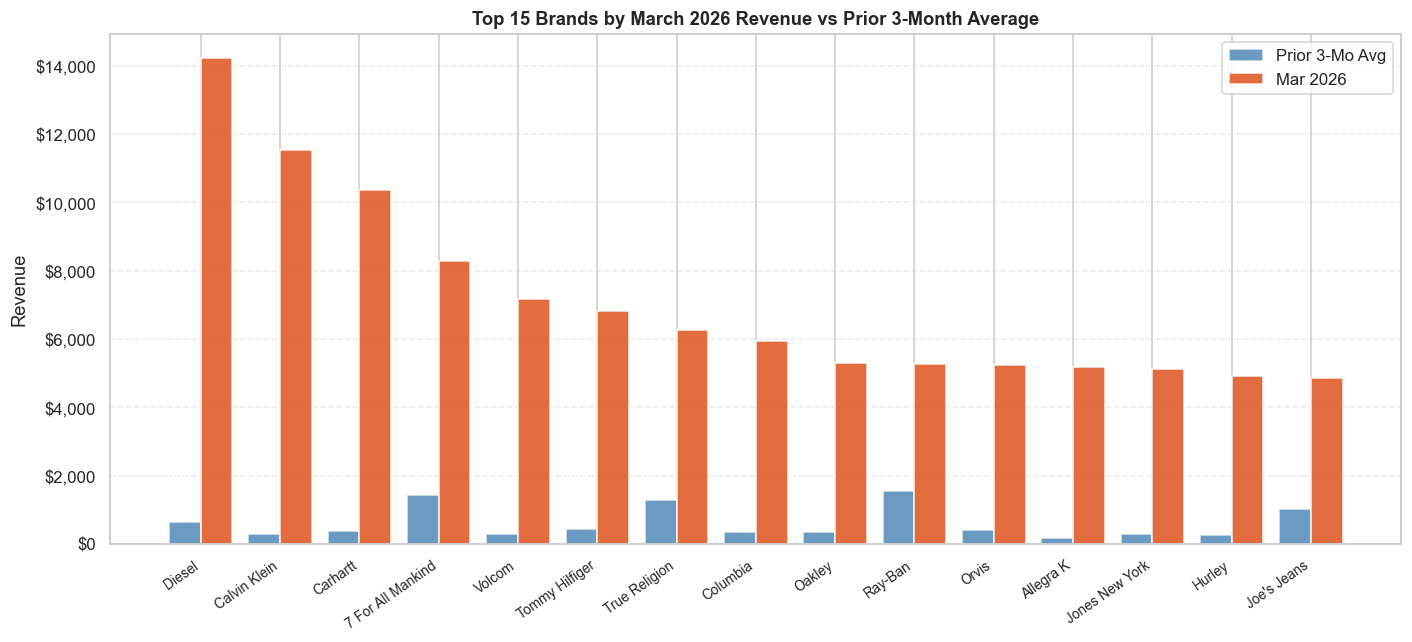

                   Mar 2026  Prior 3-Mo Avg  Change %
brand                                                
Diesel              14231.0           637.0    2132.0
Calvin Klein        11537.0           298.0    3778.0
Carhartt            10354.0           387.0    2577.0
7 For All Mankind    8275.0          1425.0     481.0
Volcom               7175.0           284.0    2423.0
Tommy Hilfiger       6813.0           433.0    1475.0
True Religion        6257.0          1294.0     384.0
Columbia             5945.0           337.0    1666.0
Oakley               5302.0           346.0    1431.0
Ray-Ban              5257.0          1551.0     239.0
Orvis                5232.0           400.0    1209.0
Allegra K            5168.0           160.0    3130.0
Jones New York       5133.0           294.0    1644.0
Hurley               4929.0           259.0    1806.0
Joe's Jeans          4872.0          1020.0     378.0


In [5]:
brands = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', o.created_at) AS month,
        p.brand,
        p.category,
        ROUND(SUM(i.sale_price), 2)             AS revenue
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`      o
    JOIN `{BQ_PROJECT}.{DATASET}.fct_order_items` i USING (order_id)
    JOIN `{BQ_PROJECT}.{DATASET}.dim_products`    p ON i.product_id = p.product_id
    WHERE o.order_status NOT IN ('Cancelled', 'Returned')
      AND o.created_at >= '2025-12-01'
    GROUP BY 1, 2, 3
""")

# Top 15 brands in March 2026
top_brands_mar = (
    brands[brands['month'] == HIGHLIGHT_MONTH]
    .groupby('brand')['revenue'].sum()
    .sort_values(ascending=False)
    .head(15)
)

# Prior 3-month average for the same brands
prior_brands = (
    brands[brands['month'] < HIGHLIGHT_MONTH]
    .groupby('brand')['revenue'].mean()
)

brand_cmp = pd.DataFrame({'Mar 2026': top_brands_mar, 'Prior 3-Mo Avg': prior_brands}).loc[top_brands_mar.index]
brand_cmp['Change %'] = ((brand_cmp['Mar 2026'] / brand_cmp['Prior 3-Mo Avg']) - 1) * 100

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(top_brands_mar))
width = 0.4
ax.bar([i - width/2 for i in x], brand_cmp['Prior 3-Mo Avg'], width, label='Prior 3-Mo Avg', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], brand_cmp['Mar 2026'],       width, label='Mar 2026',       color='#e05c2a', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(top_brands_mar.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Top 15 Brands by March 2026 Revenue vs Prior 3-Month Average', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue')
fmt_currency(ax)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

print(brand_cmp.round(0).to_string())


## 5 — Customer Mix: New vs. Returning

Is March 2026 being driven by new customer acquisition or by existing customers buying more?
A customer is "new" if their first order falls in March 2026.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


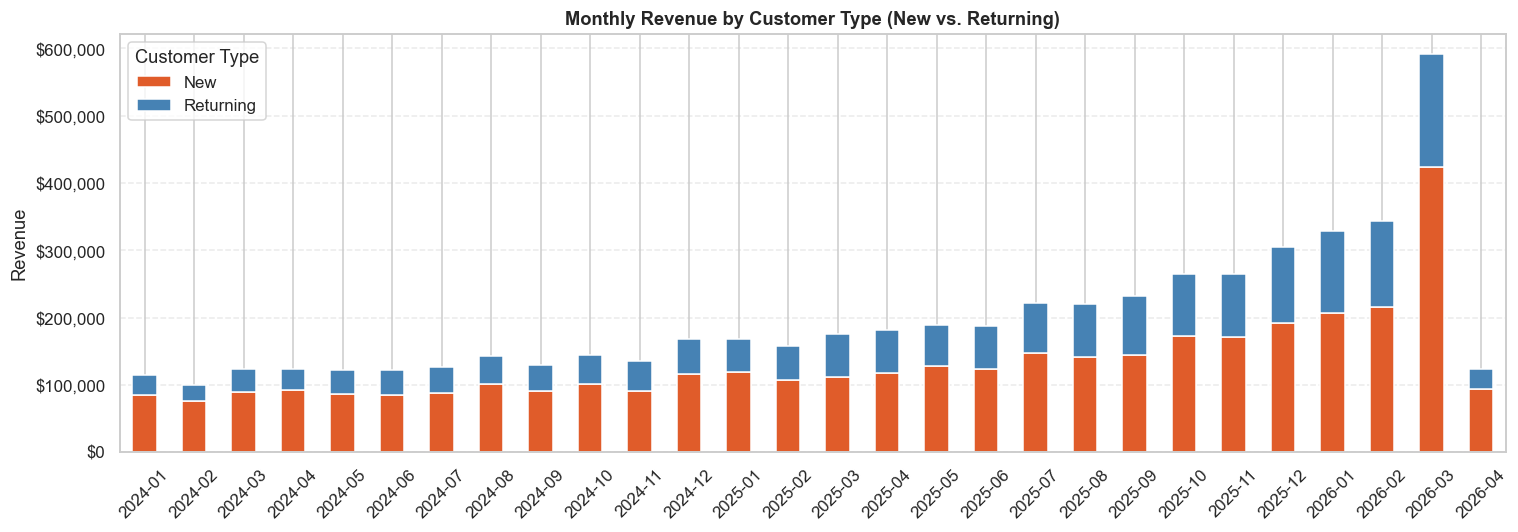


March 2026 customer mix:
customer_type  orders   revenue  rev_share
          New    4960 423166.88  71.470486
    Returning    2008 168919.31  28.529514


In [6]:
cust_mix = q(f"""
    WITH first_orders AS (
        SELECT user_id, MIN(created_at) AS first_order_at
        FROM `{BQ_PROJECT}.{DATASET}.fct_orders`
        WHERE order_status NOT IN ('Cancelled', 'Returned')
        GROUP BY user_id
    )
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', o.created_at)                          AS month,
        CASE
            WHEN FORMAT_TIMESTAMP('%Y-%m', f.first_order_at)
                 = FORMAT_TIMESTAMP('%Y-%m', o.created_at) THEN 'New'
            ELSE 'Returning'
        END                                                              AS customer_type,
        COUNT(DISTINCT o.order_id)                                       AS orders,
        ROUND(SUM(o.revenue_amt), 2)                                   AS revenue
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders` o
    JOIN first_orders f USING (user_id)
    WHERE o.order_status NOT IN ('Cancelled', 'Returned')
      AND o.created_at >= '2024-01-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

cust_pivot = cust_mix.pivot_table(index='month', columns='customer_type', values='revenue', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
cust_pivot.plot(kind='bar', stacked=True, ax=ax, color=['#e05c2a', 'steelblue'], edgecolor='white')
ax.set_title('Monthly Revenue by Customer Type (New vs. Returning)', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
fmt_currency(ax)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.legend(title='Customer Type')
plt.tight_layout()
plt.show()

# March share
mar_mix = cust_mix[cust_mix['month'] == HIGHLIGHT_MONTH].copy()
mar_mix['rev_share'] = mar_mix['revenue'] / mar_mix['revenue'].sum() * 100
print('\nMarch 2026 customer mix:')
print(mar_mix[['customer_type', 'orders', 'revenue', 'rev_share']].to_string(index=False))

## 6 — Traffic Source

Which acquisition channels are bringing in customers, and are channel volumes shifting?

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


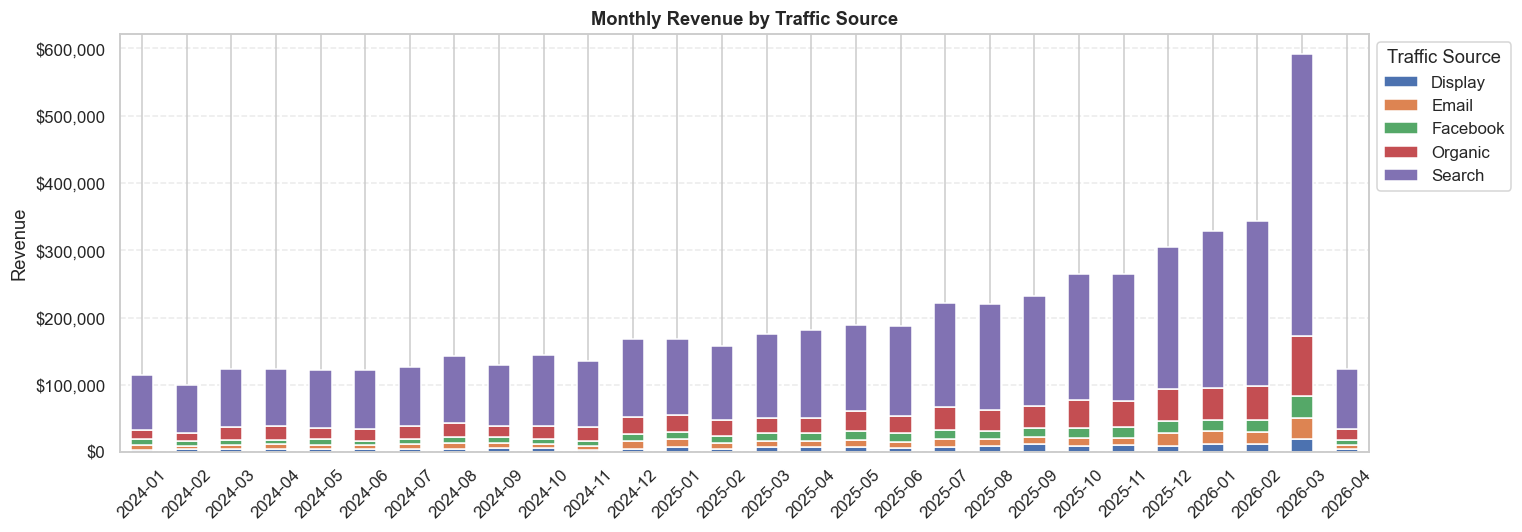


March 2026 vs prior average by traffic source:
traffic_source  orders   revenue  rev_share     prior_avg  change_pct
        Search    4881 419062.16  70.777222 129712.370000  223.070313
       Organic    1012  88748.98  14.989199  26600.713462  233.633833
      Facebook     429  33781.19   5.705451  10989.652308  207.390890
         Email     377  29778.29   5.029384   9745.648846  205.554720
       Display     269  20715.57   3.498742   7534.623077  174.938372


In [7]:
traffic = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', o.created_at) AS month,
        u.traffic_source,
        COUNT(DISTINCT o.order_id)              AS orders,
        ROUND(SUM(o.revenue_amt), 2)          AS revenue
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`   o
    JOIN `{BQ_PROJECT}.{DATASET}.dim_users`    u USING (user_id)
    WHERE o.order_status NOT IN ('Cancelled', 'Returned')
      AND o.created_at >= '2024-01-01'
    GROUP BY 1, 2
    ORDER BY 1, 4 DESC
""")

traffic_pivot = traffic.pivot_table(index='month', columns='traffic_source', values='revenue', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
traffic_pivot.plot(kind='bar', stacked=True, ax=ax, edgecolor='white')
ax.set_title('Monthly Revenue by Traffic Source', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
fmt_currency(ax)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.legend(title='Traffic Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# March 2026 share vs prior avg
mar_traffic = traffic[traffic['month'] == HIGHLIGHT_MONTH][['traffic_source', 'orders', 'revenue']].copy()
mar_traffic['rev_share'] = mar_traffic['revenue'] / mar_traffic['revenue'].sum() * 100
prior_traffic = (
    traffic[traffic['month'] < HIGHLIGHT_MONTH]
    .groupby('traffic_source')['revenue'].mean()
    .rename('prior_avg')
)
mar_traffic = mar_traffic.merge(prior_traffic, on='traffic_source')
mar_traffic['change_pct'] = ((mar_traffic['revenue'] / mar_traffic['prior_avg']) - 1) * 100
print('\nMarch 2026 vs prior average by traffic source:')
print(mar_traffic.sort_values('revenue', ascending=False).to_string(index=False))

## 7 — Geography

Top countries by revenue in March 2026, compared to prior month average.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


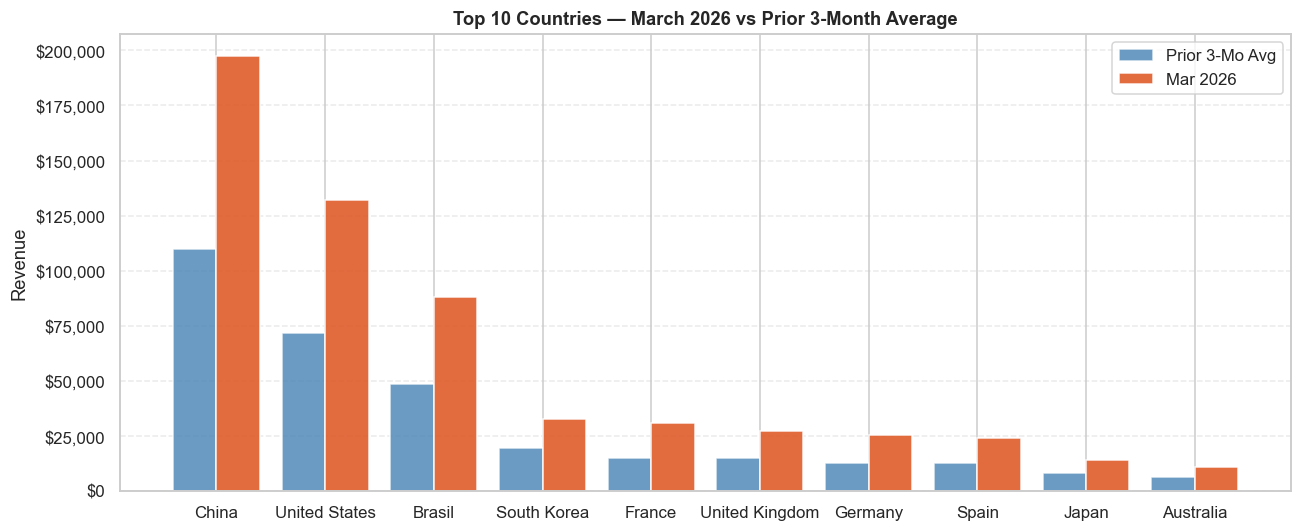

                Mar 2026  Prior 3-Mo Avg  Change %
country                                           
China           197595.0        109676.0      80.0
United States   132093.0         71977.0      84.0
Brasil           88137.0         48639.0      81.0
South Korea      32813.0         19491.0      68.0
France           30912.0         15103.0     105.0
United Kingdom   27175.0         15126.0      80.0
Germany          25632.0         13072.0      96.0
Spain            24079.0         12962.0      86.0
Japan            14296.0          8217.0      74.0
Australia        11156.0          6694.0      67.0


In [8]:
geo = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', o.created_at) AS month,
        u.country,
        COUNT(DISTINCT o.order_id)              AS orders,
        ROUND(SUM(o.revenue_amt), 2)          AS revenue
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`   o
    JOIN `{BQ_PROJECT}.{DATASET}.dim_users`    u USING (user_id)
    WHERE o.order_status NOT IN ('Cancelled', 'Returned')
      AND o.created_at >= '2025-12-01'
    GROUP BY 1, 2
    ORDER BY 1, 4 DESC
""")

# Top 10 countries in March 2026
top_countries = (
    geo[geo['month'] == HIGHLIGHT_MONTH]
    .groupby('country')['revenue'].sum()
    .sort_values(ascending=False)
    .head(10)
)
prior_geo = (
    geo[geo['month'] < HIGHLIGHT_MONTH]
    .groupby('country')['revenue'].mean()
)
geo_cmp = pd.DataFrame({'Mar 2026': top_countries, 'Prior 3-Mo Avg': prior_geo}).loc[top_countries.index]
geo_cmp['Change %'] = ((geo_cmp['Mar 2026'] / geo_cmp['Prior 3-Mo Avg']) - 1) * 100

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(geo_cmp))
width = 0.4
ax.bar([i - width/2 for i in x], geo_cmp['Prior 3-Mo Avg'], width, label='Prior 3-Mo Avg', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], geo_cmp['Mar 2026'],       width, label='Mar 2026',       color='#e05c2a', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(geo_cmp.index, rotation=0, ha='center')
ax.set_title('Top 10 Countries — March 2026 vs Prior 3-Month Average', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue')
fmt_currency(ax)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

print(geo_cmp.round(0).to_string())

## 8 — Margin Check

Revenue growth is only valuable if margins hold. Compare gross profit and gross margin %
across months to confirm the spike is profitable.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


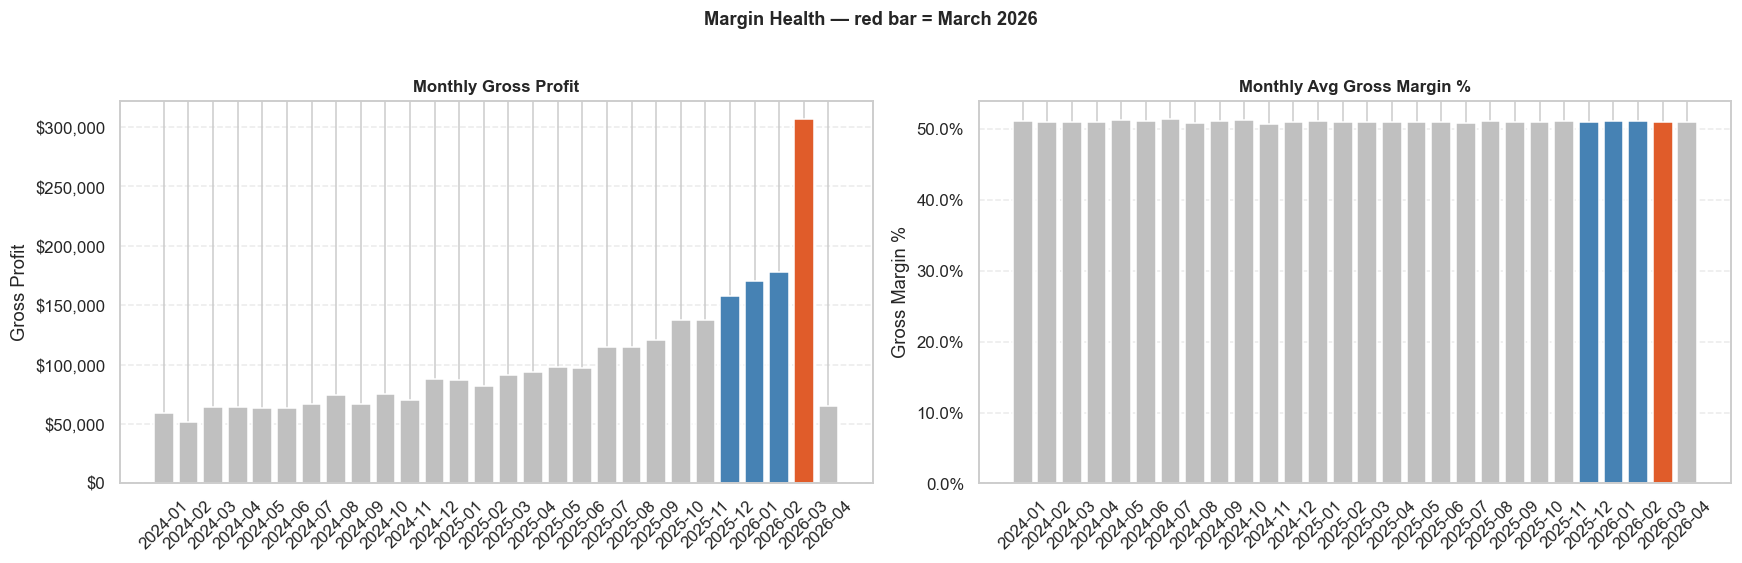

  month   revenue  gross_profit  avg_gross_margin_pct
2025-11 264794.56     137835.16                 51.17
2025-12 304550.59     157877.10                 50.92
2026-01 328797.43     170697.10                 51.18
2026-02 343115.52     177793.36                 51.10
2026-03 592086.19     306851.54                 51.03
2026-04 124512.25      65174.65                 51.05


In [9]:
margins = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', o.created_at)  AS month,
        ROUND(SUM(i.sale_price), 2)              AS revenue,
        ROUND(SUM(i.gross_profit), 2)            AS gross_profit,
        ROUND(AVG(i.gross_margin_pct), 2)        AS avg_gross_margin_pct
    FROM `{BQ_PROJECT}.{DATASET}.fct_orders`      o
    JOIN `{BQ_PROJECT}.{DATASET}.fct_order_items` i USING (order_id)
    WHERE o.order_status NOT IN ('Cancelled', 'Returned')
      AND o.created_at >= '2024-01-01'
    GROUP BY 1
    ORDER BY 1
""")

colors = [bar_color(m) for m in margins['month']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(margins['month'], margins['gross_profit'], color=colors, edgecolor='white')
axes[0].set_title('Monthly Gross Profit', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Gross Profit')
axes[0].tick_params(axis='x', rotation=45)
fmt_currency(axes[0])
axes[0].grid(axis='y', alpha=0.4, linestyle='--')

axes[1].bar(margins['month'], margins['avg_gross_margin_pct'], color=colors, edgecolor='white')
axes[1].set_title('Monthly Avg Gross Margin %', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Gross Margin %')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('Margin Health — red bar = March 2026', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(margins.tail(6).to_string(index=False))

## 9 — Funnel: Is Site Traffic Increasing?

`fct_funnel` gives one row per session. Total sessions per month shows raw traffic volume.
We can also see if more sessions are reaching deeper funnel stages (product, cart, purchase).

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


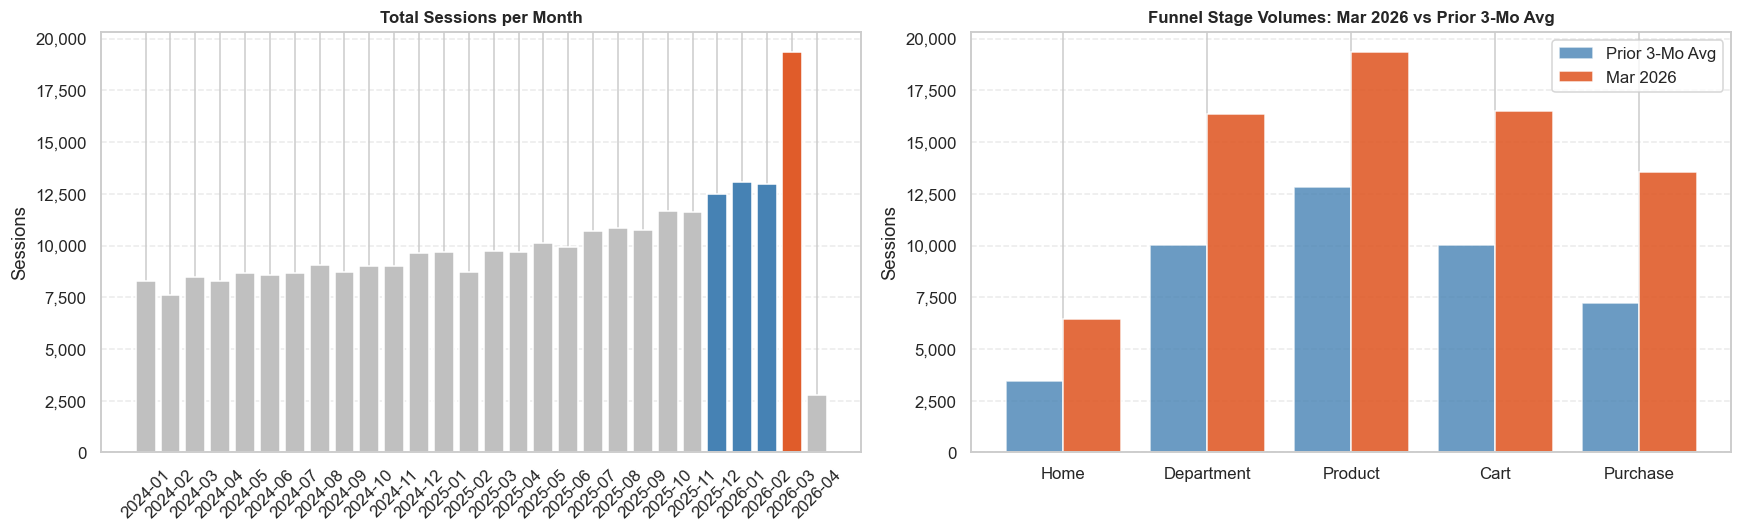

  month  total_sessions  home_visits  dept_visits  product_visits  cart_adds  purchases
2025-11           11610         2863         8711           11610       8769       5898
2025-12           12496         3206         9557           12496       9604       6720
2026-01           13070         3486        10176           13070      10153       7259
2026-02           12956         3723        10319           12956      10364       7700
2026-03           19355         6449        16378           19355      16501      13530
2026-04            2754         1229         2675            2754       2655       2553


In [10]:
traffic_vol = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', session_start_at)  AS month,
        COUNT(*)                                      AS total_sessions,
        COUNTIF(visited_home = 1)                     AS home_visits,
        COUNTIF(visited_department = 1)               AS dept_visits,
        COUNTIF(visited_product = 1)                  AS product_visits,
        COUNTIF(added_to_cart = 1)                    AS cart_adds,
        COUNTIF(purchased = 1)                        AS purchases
    FROM `{BQ_PROJECT}.{DATASET}.fct_funnel`
    WHERE session_start_at >= '2024-01-01'
    GROUP BY 1
    ORDER BY 1
""")

colors = [bar_color(m) for m in traffic_vol['month']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total sessions
axes[0].bar(traffic_vol['month'], traffic_vol['total_sessions'], color=colors, edgecolor='white')
axes[0].set_title('Total Sessions per Month', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Sessions')
axes[0].tick_params(axis='x', rotation=45)
fmt_comma(axes[0])
axes[0].grid(axis='y', alpha=0.4, linestyle='--')

# Funnel stage volumes for March 2026 vs prior avg
mar_funnel   = traffic_vol[traffic_vol['month'] == HIGHLIGHT_MONTH].iloc[0]
prior_funnel = traffic_vol[traffic_vol['month'] < HIGHLIGHT_MONTH].tail(3).mean(numeric_only=True)
stages = ['home_visits', 'dept_visits', 'product_visits', 'cart_adds', 'purchases']
labels = ['Home', 'Department', 'Product', 'Cart', 'Purchase']
x = range(len(stages))
width = 0.4
axes[1].bar([i - width/2 for i in x], [prior_funnel[s] for s in stages], width,
            label='Prior 3-Mo Avg', color='steelblue', alpha=0.8)
axes[1].bar([i + width/2 for i in x], [mar_funnel[s] for s in stages], width,
            label='Mar 2026', color='#e05c2a', alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Funnel Stage Volumes: Mar 2026 vs Prior 3-Mo Avg', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Sessions')
fmt_comma(axes[1])
axes[1].grid(axis='y', alpha=0.4, linestyle='--')
axes[1].legend()

plt.tight_layout()
plt.show()

print(traffic_vol.tail(6).to_string(index=False))


## 10 — Funnel: Is Conversion Rate Shifting?

Conversion rate = sessions that resulted in a purchase / total sessions.
We also break it down by traffic source (joined from `dim_users`) to see if any
channel is converting at a materially different rate in March 2026.

/Users/marcalexander/projects/evidence_project/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


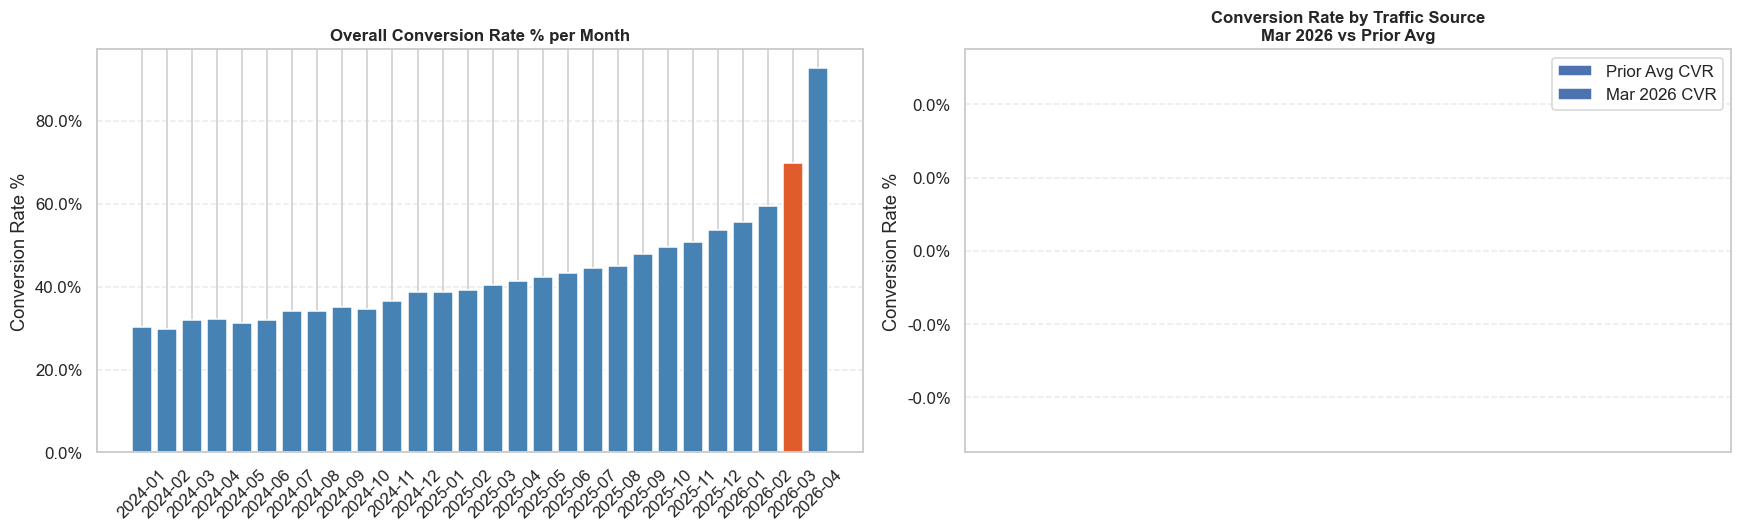


Conversion rate trend (last 6 months):
  month  total_sessions  converted_sessions  conversion_rate_pct  pct_reached_cart
2025-11           11610                5898                50.80             75.53
2025-12           12496                6720                53.78             76.86
2026-01           13070                7259                55.54             77.68
2026-02           12956                7700                59.43             79.99
2026-03           19355               13530                69.90             85.25
2026-04            2754                2553                92.70             96.41

March 2026 conversion by traffic source vs prior avg:
Empty DataFrame
Columns: [traffic_source, sessions, conversion_rate_pct, prior_avg_cvr]
Index: []


In [11]:
conversion = q(f"""
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', f.session_start_at)        AS month,
        COUNT(*)                                              AS total_sessions,
        COUNTIF(f.purchased = 1)                             AS converted_sessions,
        ROUND(COUNTIF(f.purchased = 1) / COUNT(*) * 100, 2) AS conversion_rate_pct,
        -- Stage drop-off rates
        ROUND(COUNTIF(f.visited_department = 1) / COUNT(*) * 100, 2) AS pct_reached_dept,
        ROUND(COUNTIF(f.visited_product = 1)   / COUNT(*) * 100, 2) AS pct_reached_product,
        ROUND(COUNTIF(f.added_to_cart = 1)     / COUNT(*) * 100, 2) AS pct_reached_cart
    FROM `{BQ_PROJECT}.{DATASET}.fct_funnel` f
    WHERE f.session_start_at >= '2024-01-01'
    GROUP BY 1
    ORDER BY 1
""")

conversion_by_source = q(f"""
    -- traffic_source is now a column on fct_funnel (added via int_funnel_events);
    -- no join to dim_users needed, so anonymous sessions are included correctly.
    SELECT
        FORMAT_TIMESTAMP('%Y-%m', f.session_start_at)         AS month,
        f.traffic_source,
        COUNT(*)                                               AS sessions,
        COUNTIF(f.purchased = 1)                              AS conversions,
        ROUND(COUNTIF(f.purchased = 1) / COUNT(*) * 100, 2)  AS conversion_rate_pct
    FROM `{BQ_PROJECT}.{DATASET}.fct_funnel`  f
    WHERE f.session_start_at >= '2024-01-01'
    GROUP BY 1, 2
    ORDER BY 1, 5 DESC
""")

colors = ['#e05c2a' if m == HIGHLIGHT_MONTH else 'steelblue' for m in conversion['month']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall conversion rate trend
axes[0].bar(conversion['month'], conversion['conversion_rate_pct'], color=colors, edgecolor='white')
axes[0].set_title('Overall Conversion Rate % per Month', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Conversion Rate %')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[0].grid(axis='y', alpha=0.4, linestyle='--')

# Conversion rate by traffic source — March 2026 vs prior avg
mar_src  = conversion_by_source[conversion_by_source['month'] == HIGHLIGHT_MONTH]
prior_src = (
    conversion_by_source[conversion_by_source['month'] < HIGHLIGHT_MONTH]
    .groupby('traffic_source')['conversion_rate_pct'].mean(numeric_only=True)
    .rename('prior_avg_cvr')
)
src_cmp = mar_src[['traffic_source', 'sessions', 'conversion_rate_pct']].merge(
    prior_src, on='traffic_source'
).sort_values('conversion_rate_pct', ascending=False)

x = range(len(src_cmp))
width = 0.4
axes[1].bar([i - width/2 for i in x], src_cmp['prior_avg_cvr'],        width,
            label='Prior Avg CVR', color='steelblue', alpha=0.8)
axes[1].bar([i + width/2 for i in x], src_cmp['conversion_rate_pct'],  width,
            label='Mar 2026 CVR', color='#e05c2a', alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(src_cmp['traffic_source'], rotation=20, ha='right')
axes[1].set_title('Conversion Rate by Traffic Source\nMar 2026 vs Prior Avg',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Conversion Rate %')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].grid(axis='y', alpha=0.4, linestyle='--')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nConversion rate trend (last 6 months):')
print(conversion[['month', 'total_sessions', 'converted_sessions',
                   'conversion_rate_pct', 'pct_reached_cart']].tail(6).to_string(index=False))

print('\nMarch 2026 conversion by traffic source vs prior avg:')
print(src_cmp.to_string(index=False))


## Summary

Run this cell last to print a concise fact sheet for the investigation.

In [12]:
mar = monthly_rev[monthly_rev['month'] == HIGHLIGHT_MONTH].iloc[0]
prev = monthly_rev[monthly_rev['month'] < HIGHLIGHT_MONTH].iloc[-1]

print('=' * 60)
print('  Revenue Growth Investigation — March 2026')
print('=' * 60)
print(f'  March 2026 Revenue   : ${mar["revenue"]:>12,.0f}')
print(f'  Prior Month Revenue  : ${prev["revenue"]:>12,.0f}')
print(f'  MoM Change           : {((mar["revenue"] / prev["revenue"]) - 1) * 100:>11.1f}%')
print(f'  March 2026 Orders    : {int(mar["orders"]):>12,}')
print(f'  Prior Month Orders   : {int(prev["orders"]):>12,}')
print('=' * 60)
print('  See charts above for category, brand, customer,')
print('  traffic source, geography, and margin breakdowns.')
print('=' * 60)

  Revenue Growth Investigation — March 2026
  March 2026 Revenue   : $     592,086
  Prior Month Revenue  : $     343,116
  MoM Change           :        72.6%
  March 2026 Orders    :        6,968
  Prior Month Orders   :        3,979
  See charts above for category, brand, customer,
  traffic source, geography, and margin breakdowns.
